In [1]:
from langchain.agents import create_agent
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Annotated
import os
import json
from modelConfig import ModelConfigManager
from langchain_core.tools import tool 
from langchain_core.messages import HumanMessage
import lease_extractor
from duckduckgo_search import DDGS
import razorpay
from dotenv import load_dotenv
load_dotenv()

/Users/anshagarwal/Developer/KirayaEase/venv/lib/python3.13/site-packages/razorpay/client.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


True

In [12]:
llm = ModelConfigManager('gpt-4o-mini', 0, 3).model()

In [ ]:
@tool
def extract_lease_details(pdf_path: str) -> str:
    """Extracts lease details from a PDF file"""
    result = lease_extractor.extract_from_pdf(pdf_path)
    return json.dumps(result, ensure_ascii=False, indent=2)


# --- Define State with Shared Fields ---
class AgentState(TypedDict):
    user_query: str
    answer: str
    # # Shared state fields for agent collaboration
    # lease_id: Annotated[str | None, "Lease identifier for tracking"]
    # tenant: Annotated[str | None, "Tenant name or identifier"]
    # rent: Annotated[float | None, "Rent amount"]
    # payment_status: Annotated[str | None, "Payment status (pending, paid, overdue, etc.)"]
    # # Agent communication
    # next_agent: Annotated[str | None, "Next agent to call (for agent-to-agent communication)"]
    # agent_history: Annotated[list, "History of agents that have been called"]

# --- Define Node ---
def lease_agent(state: AgentState) -> str:
    """
    Executes a ReAct-style agent that processes a user query.

    This function takes the current state (which includes the user's question),
    creates an agent using the OpenAI model and the `extract_lease_details` tool,
    then runs the agent to get a response. The final answer is returned as updated state.

    Args:
        state (AgentState): A dictionary with the user's query.

    Returns:
        dict: Updated state with the generated answer.
    """
    agent = create_agent(llm, [extract_lease_details], system_prompt="You are a helpful assistant with access to tools.")
    result = agent.invoke({"messages": state["user_query"]})
    return {"answer": result["messages"][-1].content}

In [4]:
# --- Define Graph ---
workflow = StateGraph(AgentState)

workflow.add_node("lease_agent", lease_agent)

workflow.add_edge(START, "lease_agent")
workflow.add_edge("lease_agent", END)

app = workflow.compile()

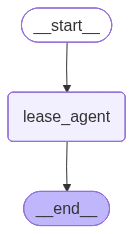

In [5]:
from IPython.display import Image, display
Image(app.get_graph().draw_mermaid_png())

In [16]:
# # --- Run Graph ---
# result = app.invoke({"user_query": "/Users/anshagarwal/Developer/KirayaEase/data/Lease_Agreement_Sample.pdf"})
# print(result["answer"])

In [6]:
from typing import Literal

# We'll define agent_docs after all agents are defined
agent_docs = {}

def orchestrator_logic(state: AgentState) -> Literal["lease_agent", "reminder_agent", "insights_agent", "payments_agent", "onboarding_agent", END]:
    """
    Orchestrator that coordinates between agents and allows agent-to-agent communication.
    Checks if an agent has requested to call another agent, otherwise routes to the appropriate agent.
    """
    # Check if an agent has requested to call another agent
    if state.get("next_agent") and state["next_agent"] in ["lease_agent", "reminder_agent", "insights_agent", "payments_agent", "onboarding_agent"]:
        next_agent = state["next_agent"]
        # Clear the next_agent flag
        state["next_agent"] = None
        return next_agent
    
    # If no agent-to-agent call requested, use routing logic
    return routing_logic(state)

def routing_logic(state: AgentState) -> Literal["lease_agent", "reminder_agent", "insights_agent", "payments_agent", "onboarding_agent"]:
    """
    Uses the LLM to choose between 'lease_agent', 'reminder_agent', 'insights_agent', 'payments_agent', and 'onboarding_agent'
    based on the intent of the user query and the agents' docstrings.

    Args:
        state (AgentState): The current state containing the user query.

    Returns:
        str: The name of the next node to route to.
    """
    prompt = f"""
    You are a router agent. Your task is to choose the best agent for the job.
    Here is the user query: {state['user_query']}

    You can choose from the following agents:
    - lease_agent: {agent_docs.get('lease_agent', 'Handles lease-related queries and document processing')}
    - reminder_agent: {agent_docs.get('reminder_agent', 'Handles reminders for rent payments, and important dates')}
    - insights_agent: {agent_docs.get('insights_agent', 'Handles quantitative insights about the property and pricing recommendations')}
    - payments_agent: {agent_docs.get('payments_agent', 'Handles rent payment processing and payment-related queries')}
    - onboarding_agent: {agent_docs.get('onboarding_agent', 'Handles user onboarding, profile setup, KYC verification, and account setup queries')}

    Which agent should handle this query? Respond with just the agent name (either "lease_agent", "reminder_agent", "insights_agent", "payments_agent", or "onboarding_agent").
    """
    response = llm.invoke(prompt)
    decision = response.content.strip().lower()
    
    # Parse the response to determine which agent to route to
    if "lease" in decision:
        return "lease_agent"
    elif "reminder" in decision:
        return "reminder_agent"
    elif "insights" in decision:
        return "insights_agent"
    elif "payment" in decision:
        return "payments_agent"
    elif "onboard" in decision:
        return "onboarding_agent"
    else:
        # Default to lease_agent if unclear
        return "lease_agent"

In [7]:
# --- Lease Agent ---
def lease_agent(state: AgentState) -> AgentState:
    """
    Handles lease-related queries including lease document processing and extraction.
    Can call other agents (payments_agent, reminder_agent, insights_agent) if needed.
    """
    print("--- Lease Agent ---")
    
    # Initialize agent history if not present
    if 'agent_history' not in state:
        state['agent_history'] = []
    state['agent_history'].append('lease_agent')
    
    agent = create_agent(llm, [extract_lease_details])
    result = agent.invoke({"messages": [HumanMessage(content=state["user_query"])]})
    state['answer'] = result["messages"][-1].content
    
    # Extract and store lease information in shared state
    answer_lower = state['answer'].lower()
    if 'rent' in answer_lower or 'lease' in answer_lower:
        # Store extracted information in shared state
        if state.get('lease_id') is None:
            state['lease_id'] = f"lease_{hash(state['user_query']) % 10000}"
        if 'tenant' in answer_lower and state.get('tenant') is None:
            state['tenant'] = "Tenant"  # Would extract from actual response
        # Try to extract rent amount
        import re
        rent_match = re.search(r'₹?\s*(\d+(?:,\d+)*)', state['answer'])
        if rent_match and state.get('rent') is None:
            rent_str = rent_match.group(1).replace(',', '')
            try:
                state['rent'] = float(rent_str)
            except:
                pass
    
    # Check if we need to call another agent based on the query or extracted data
    query_lower = state['user_query'].lower()
    if 'payment' in query_lower or 'pay' in query_lower:
        state['next_agent'] = 'payments_agent'
    elif 'reminder' in query_lower or 'remind' in query_lower:
        state['next_agent'] = 'reminder_agent'
    elif 'insight' in query_lower or 'price' in query_lower or 'market' in query_lower:
        state['next_agent'] = 'insights_agent'
    
    return state

# --- Reminder Agent ---
def reminder_agent(state: AgentState) -> AgentState:
    """
    Handles reminders for rent payments, lease renewals, and important dates.
    Can access shared state (lease_id, tenant, rent) and call other agents if needed.
    """
    print("--- Reminder Agent ---")
    
    # Initialize agent history if not present
    if 'agent_history' not in state:
        state['agent_history'] = []
    state['agent_history'].append('reminder_agent')
    
    # Build context from shared state
    context = ""
    if state.get('lease_id'):
        context += f"\nLease ID: {state['lease_id']}"
    if state.get('tenant'):
        context += f"\nTenant: {state['tenant']}"
    if state.get('rent'):
        context += f"\nRent Amount: ₹{state['rent']:,.0f}"
    if state.get('payment_status'):
        context += f"\nPayment Status: {state['payment_status']}"
    
    prompt = f"""You are a reminder assistant for lease management. Help the user with reminders,
    notifications, and scheduling related to rent payments, lease renewals, and important dates.
    
    User query: {state['user_query']}
    {context}
    
    Provide a helpful response about setting reminders, checking upcoming dates, or managing notifications.
    Use the shared state information if available."""
    response = llm.invoke(prompt)
    state['answer'] = response.content.strip()
    
    # Update payment status if reminder is about overdue payment
    if 'overdue' in state['answer'].lower() or 'late' in state['answer'].lower():
        state['payment_status'] = 'overdue'
    
    # Check if we need to call another agent
    query_lower = state['user_query'].lower()
    if 'payment' in query_lower or 'pay' in query_lower:
        state['next_agent'] = 'payments_agent'
    elif 'insight' in query_lower or 'price' in query_lower:
        state['next_agent'] = 'insights_agent'
    
    return state

def insights_agent(state: AgentState) -> AgentState:
    """
    Provides quantitative insights about the property and pricing recommendations.
    Uses web search to get current market data and trends.
    Can access shared state (rent, lease_id) for context.
    """
    print("--- Insights Agent ---")
    
    # Initialize agent history if not present
    if 'agent_history' not in state:
        state['agent_history'] = []
    state['agent_history'].append('insights_agent')
    
    # Build context from shared state
    context = ""
    if state.get('rent'):
        context += f"\nCurrent Rent: ₹{state['rent']:,.0f}"
    if state.get('lease_id'):
        context += f"\nLease ID: {state['lease_id']}"
    
    query_with_context = state["user_query"] + context
    
    # Use create_agent with web_search tool for ReAct-style reasoning
    agent = create_agent(llm, [web_search])
    result = agent.invoke({"messages": [HumanMessage(content=query_with_context)]})
    state['answer'] = result["messages"][-1].content
    
    # Insights agent typically doesn't call other agents, but can if needed
    return state

def payments_agent(state: AgentState) -> AgentState:
    """
    Handles rent payment processing and payment-related queries.
    Uses the process_payments tool to create Razorpay payment orders.
    Can access shared state (rent, lease_id, tenant) and call reminder_agent.
    """
    print("--- Payments Agent ---")
    
    # Initialize agent history if not present
    if 'agent_history' not in state:
        state['agent_history'] = []
    state['agent_history'].append('payments_agent')
    
    # Build context from shared state
    context = ""
    if state.get('rent'):
        context += f"\nRent Amount: ₹{state['rent']:,.0f}"
    if state.get('lease_id'):
        context += f"\nLease ID: {state['lease_id']}"
    if state.get('tenant'):
        context += f"\nTenant: {state['tenant']}"
    
    query_with_context = state["user_query"] + context
    
    # Use create_agent with process_payments tool for ReAct-style reasoning
    agent = create_agent(llm, [process_payments])
    result = agent.invoke({"messages": [HumanMessage(content=query_with_context)]})
    state['answer'] = result["messages"][-1].content
    
    # Update payment status after processing
    if 'success' in state['answer'].lower() or 'created' in state['answer'].lower():
        state['payment_status'] = 'paid'
    elif 'pending' in state['answer'].lower():
        state['payment_status'] = 'pending'
    
    # Check if we need to call reminder_agent to set up reminders
    query_lower = state['user_query'].lower()
    if 'reminder' in query_lower or 'remind' in query_lower:
        state['next_agent'] = 'reminder_agent'
    
    return state

def onboarding_agent(state: AgentState) -> AgentState:
    """
    Handles user onboarding, profile setup, KYC verification, and account setup queries.
    Typically doesn't call other agents, but can if needed.
    """
    print("--- Onboarding Agent ---")
    
    # Initialize agent history if not present
    if 'agent_history' not in state:
        state['agent_history'] = []
    state['agent_history'].append('onboarding_agent')
    
    prompt = f"""You are an onboarding assistant for KirayaEase. Help users with:
    - Setting up their profile
    - Completing KYC verification (Aadhaar, PAN)
    - Understanding the onboarding process
    - Answering questions about account setup and verification requirements
    
    User query: {state['user_query']}
    
    Provide a helpful and friendly response about onboarding, profile setup, or KYC verification. 
    Guide users through the process step by step if needed."""
    response = llm.invoke(prompt)
    state['answer'] = response.content.strip()
    return state

def orchestrator(state: AgentState) -> AgentState:
    """
    Orchestrator agent that coordinates between agents and manages agent-to-agent communication.
    Checks if agents need to call each other and routes accordingly.
    """
    print("--- Orchestrator ---")
    
    # Log the orchestration
    if 'agent_history' in state and state['agent_history']:
        print(f"Agent history: {' → '.join(state['agent_history'])}")
    
    # The orchestrator doesn't modify the state, just passes through
    # The routing logic handles the actual routing
    return state


# --- Router Agent ---
def router_agent(state: AgentState) -> AgentState:
    """
    Captures a user query from the command line and updates the state.

    This function acts as an input node in the LangGraph workflow. It prompts the user
    to enter a query via the console, then stores that input in the shared state under
    the 'user_query' key, which will be used to route to the appropriate agents.

    Args:
        state (AgentState): The current state dictionary (can be empty or partially filled).

    Returns:
        dict: Updated state containing the user's query.
    """
    print("--- Router Agent ---")
    if 'user_query' not in state or not state['user_query']:
        state['user_query'] = input("Input user query: ")
    return state

# --- Update agent_docs after defining all agents ---
agent_docs = {
    "lease_agent": lease_agent.__doc__,
    "reminder_agent": reminder_agent.__doc__,
    "insights_agent": insights_agent.__doc__,
    "payments_agent": payments_agent.__doc__,
    "onboarding_agent": onboarding_agent.__doc__
}

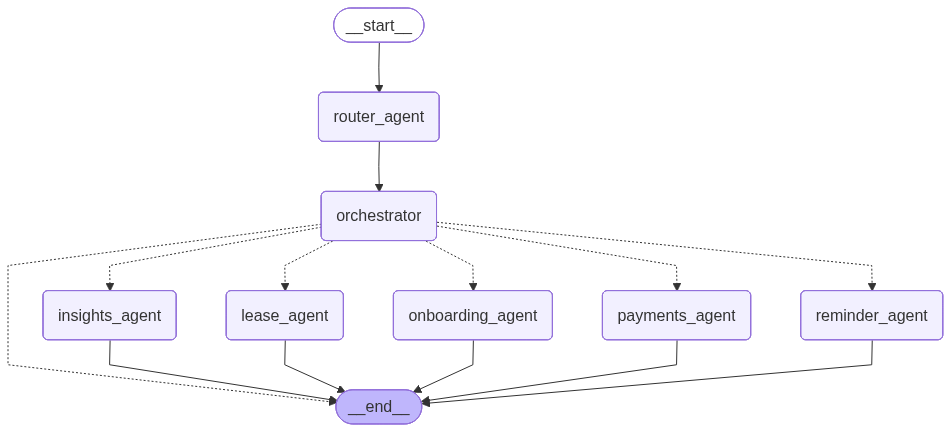

In [19]:
# --- Updated Graph with Orchestrator and Agent-to-Agent Communication ---
workflow = StateGraph(AgentState)

# Add all nodes
workflow.add_node("router_agent", router_agent)
workflow.add_node("orchestrator", orchestrator)
workflow.add_node("lease_agent", lease_agent)
workflow.add_node("reminder_agent", reminder_agent)
workflow.add_node("insights_agent", insights_agent)
workflow.add_node("payments_agent", payments_agent)
workflow.add_node("onboarding_agent", onboarding_agent)

# Define the flow
workflow.add_edge(START, "router_agent")
workflow.add_edge("router_agent", "orchestrator")

# Orchestrator routes to agents, and agents can route back to orchestrator for agent-to-agent calls
workflow.add_conditional_edges("orchestrator", orchestrator_logic)

# Agents can call back to orchestrator if they need to call another agent, otherwise end
workflow.add_conditional_edges("lease_agent", lambda s: "orchestrator" if s.get("next_agent") else END)
workflow.add_conditional_edges("reminder_agent", lambda s: "orchestrator" if s.get("next_agent") else END)
workflow.add_conditional_edges("insights_agent", lambda s: "orchestrator" if s.get("next_agent") else END)
workflow.add_conditional_edges("payments_agent", lambda s: "orchestrator" if s.get("next_agent") else END)
workflow.add_conditional_edges("onboarding_agent", lambda s: "orchestrator" if s.get("next_agent") else END)

app = workflow.compile()

from IPython.display import Image, display
Image(app.get_graph().draw_mermaid_png())

In [21]:
# --- Run Graph ---
result = app.invoke({"user_query": "Price of 4bhk in juhu tara road Mumbai?"})
print(result["answer"])

--- Router Agent ---
--- Orchestrator ---
--- Insights Agent ---


/var/folders/b8/jyn35lxn7js_l0jhxby2t1y40000gn/T/ipykernel_7856/2325838323.py:11: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/var/folders/b8/jyn35lxn7js_l0jhxby2t1y40000gn/T/ipykernel_7856/2325838323.py:11: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


I couldn't find specific current information on the prices of 4 BHK properties on Juhu Tara Road, Mumbai. However, property prices in this area can vary significantly based on factors such as the building's age, amenities, and exact location.

As of my last knowledge update, 4 BHK apartments in Juhu generally ranged from ₹4 crore to ₹10 crore or more. For the most accurate and up-to-date information, I recommend checking local real estate listings or contacting a real estate agent in Mumbai.


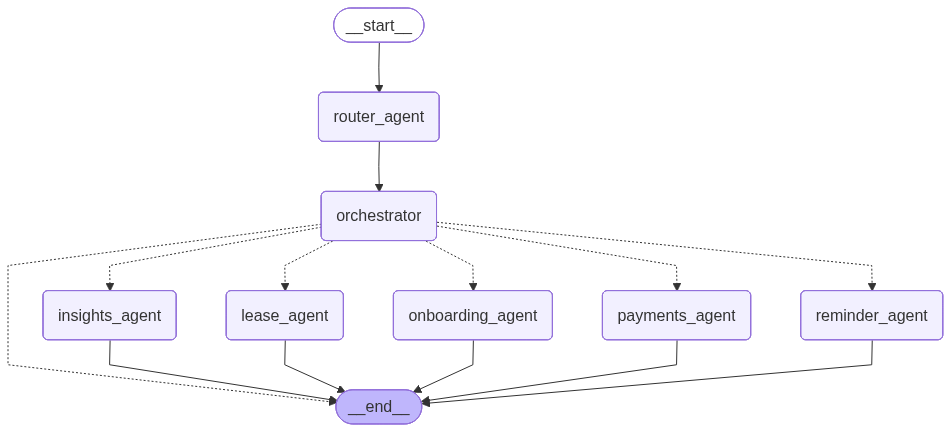

In [9]:
from IPython.display import Image, display
from chatbot import RentWiseAssistant

assistant = RentWiseAssistant()   # this internally builds the graph
display(Image(assistant.app.get_graph().draw_mermaid_png()))